# Content-Based Recommender — User Clustering

This notebook clusters users by their genre interest profiles (KMeans), then recommends courses that are popular within each cluster — a group-based collaborative content approach.

## 1. Setup

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

user_profile_df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/user_profile.csv')
test_users_df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/rs_content_test.csv')
ratings_df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML321EN-SkillsNetwork/labs/datasets/ratings.csv')

genres = ['Database','Python','CloudComputing','DataAnalysis','Containers','MachineLearning',
          'ComputerVision','DataScience','BigData','Chatbot','R','BackendDev','FrontendDev','Blockchain']
print('User profiles shape:', user_profile_df.shape)

User profiles shape: (33901, 15)


## 2. Standardize & PCA

In [11]:
X = user_profile_df[genres].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Mean after scaling (should be ~0):', X_scaled.mean(axis=0).round(3))
print('Std after scaling (should be ~1):', X_scaled.std(axis=0).round(3))

Mean after scaling (should be ~0): [-0. -0. -0. -0.  0.  0. -0. -0.  0. -0.  0.  0.  0. -0.]
Std after scaling (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


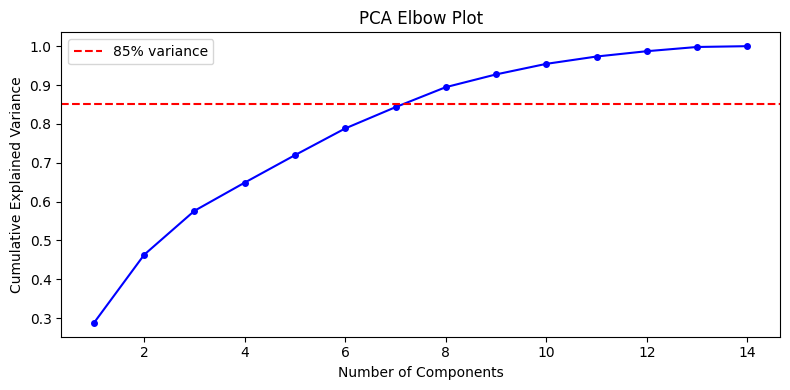

Optimal components (85% variance): 8


In [12]:
# Find optimal PCA components using cumulative variance (elbow method)
pca_full = PCA()
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, 'b-o', markersize=4)
plt.axhline(0.85, color='red', linestyle='--', label='85% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Elbow Plot')
plt.legend()
plt.tight_layout()
plt.savefig('pca_elbow.png', dpi=120, bbox_inches='tight')
plt.show()

n_components = np.argmax(cumvar >= 0.85) + 1
print(f'Optimal components (85% variance): {n_components}')

In [13]:
pca = PCA(n_components=8)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA output shape: {X_pca.shape}')
print(f'Explained variance with 8 components: {pca.explained_variance_ratio_.sum():.3f}')

PCA output shape: (33901, 8)
Explained variance with 8 components: 0.894


## 3. KMeans Clustering

In [14]:
# Silhouette analysis to find best k
sil_scores = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels, sample_size=5000, random_state=42)
    sil_scores.append(score)
    print(f'k={k}: silhouette = {score:.4f}')

k=2: silhouette = 0.4168
k=3: silhouette = 0.3583
k=4: silhouette = 0.2549
k=5: silhouette = 0.2541
k=6: silhouette = 0.2745
k=7: silhouette = 0.2885
k=8: silhouette = 0.3049


In [21]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
user_profile_df['cluster'] = kmeans.fit_predict(X_pca)

print('Cluster distribution:')
print(user_profile_df['cluster'].value_counts().sort_index())

Cluster distribution:
cluster
0     1944
1     4164
2    17139
3       20
4    10634
Name: count, dtype: int64


## 4. Generate Cluster-Based Recommendations

In [22]:
# For each cluster, find the most popular courses among cluster members
cluster_popular_courses = {}
for cluster_id in range(5):
    cluster_users = user_profile_df[user_profile_df['cluster'] == cluster_id]['user'].values
    cluster_ratings = ratings_df[ratings_df['user'].isin(cluster_users)]
    popular = (cluster_ratings.groupby('item').size()
               .sort_values(ascending=False)
               .head(50).index.tolist())
    cluster_popular_courses[cluster_id] = popular
    print(f'Cluster {cluster_id}: {len(cluster_users)} users, top course = {popular[0] if popular else "N/A"}')

Cluster 0: 1944 users, top course = BD0111EN
Cluster 1: 4164 users, top course = CO0101EN
Cluster 2: 17139 users, top course = BD0101EN
Cluster 3: 20 users, top course = GPXX0T0FEN
Cluster 4: 10634 users, top course = PY0101EN


In [23]:
# Assign test users to clusters and generate recommendations
test_user_ids = test_users_df['user'].unique()
all_recs = []
for uid in test_user_ids:
    profile = user_profile_df[user_profile_df['user'] == uid]
    if profile.empty:
        continue
    user_cluster = profile['cluster'].values[0]
    enrolled = set(test_users_df[test_users_df['user'] == uid]['item'].values)
    recs = [c for c in cluster_popular_courses[user_cluster] if c not in enrolled]
    for c in recs:
        all_recs.append({'USER': uid, 'COURSE_ID': c})

recs_df = pd.DataFrame(all_recs)
avg_recs = recs_df.groupby('USER')['COURSE_ID'].count().mean()
print(f'Average courses recommended per user: {avg_recs:.3f}')

Average courses recommended per user: 41.494


In [24]:
top10 = recs_df['COURSE_ID'].value_counts().head(10)
print('Top 10 recommended courses across all users:')
print(top10.to_string())

Top 10 recommended courses across all users:
COURSE_ID
DB0151EN      940
BC0201EN      913
WA0101EN      896
SC0101EN      893
CB0105ENv1    881
CO0201EN      879
DS0321EN      878
BD0131EN      878
DB0101EN      857
DS0301EN      856


## Summary

| Metric | Value |
|---|---|
| Scaling | StandardScaler |
| Dimensionality reduction | PCA (8 components, 85% variance) |
| Clustering | KMeans, k=5 |
| Avg recs per user | 41.494 |
| Largest cluster | Cluster 2 (17,139 users) |